# Titanic Survival Prediction

## Overview
This project builds an end-to-end classification pipeline to predict passenger survival on the **Titanic**.

* **Data Source:** [Kaggle Titanic Competition Dataset](https://www.kaggle.com/competitions/titanic/data)
* **Target Variable:** `Survived` (0 = No, 1 = Yes)
* **Goal:** Train a Scikit-Learn pipeline, evaluate accuracy, and export the trained model artifact for web deployment.
* **Tech Stack:** Python, Pandas, Scikit-Learn, Joblib

### Data Dictionary

| Feature | Definition | Key / Notes |
| :--- | :--- | :--- |
| **`Survived`** | Target variable | 0 = No, 1 = Yes |
| **`Pclass`** | Ticket class | 1 = 1st (Upper), 2 = 2nd (Middle), 3 = 3rd (Lower) |
| **`Sex`** | Gender | `male`, `female` |
| **`Age`** | Age in years | Fractional if age is less than 1 |
| **`SibSp`** | # of siblings / spouses aboard | Sibling = brother, sister, stepbrother, stepsister; Spouse = husband, wife |
| **`Parch`** | # of parents / children aboard | Parent = mother, father; Child = daughter, son, stepdaughter, stepson |
| **`Ticket`** | Ticket number | String identifier |
| **`Fare`** | Passenger fare | Continuous numeric value |
| **`Cabin`** | Cabin number | String location identifier |
| **`Embarked`** | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

In [1]:
# System & Data Processing
import os
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns 
import matplotlib.pyplot as plt

# Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Classification Models for Benchmarking
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation Metrics & Serialization
from sklearn.metrics import accuracy_score, classification_report
import joblib

## 1. Data Ingestion & Structural Inspection

We load `train.csv` from the `data/` folder and inspect the dataset.

In [2]:
data_path = os.path.join("..","data","train.csv")
df = pd.read_csv(data_path)

In [3]:
df.shape

(891, 12)

* 891 rows and 12 columns

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


* **Missing Values**: 177 in Age, 687 in Cabin and 3 in Embarked

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
770,771,0,3,"Lievens, Mr. Rene Aime",male,24.00,0,0,345781,9.5000,NaN,S
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
779,780,1,1,"Robert, Mrs. Edward Scott (Elisabeth Walton Mc...",female,43.00,0,1,24160,211.3375,B3,S
227,228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.50,0,0,A/5 21173,7.2500,NaN,S
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.00,0,1,PC 17558,247.5208,B58 B60,C


## 2. Summary Statistics & Missing Values

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.describe(include=['object', 'str'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

* **Fare:** Right-skewed (mean > median). The max value ($512) creates a high gap above the 75% mark, but it represents a valid high-paying passenger rather than a data error.
* **Age:** Standard deviation of 14.5 indicates a broad age demographic rather than a single specific group.
* **Survived:** Clean binary data (min = 0, max = 1).
* **Survival Rate:** The mean of 0.38 shows that 38% of the passengers survived.

## 3. EDA

### Univariate Analysis

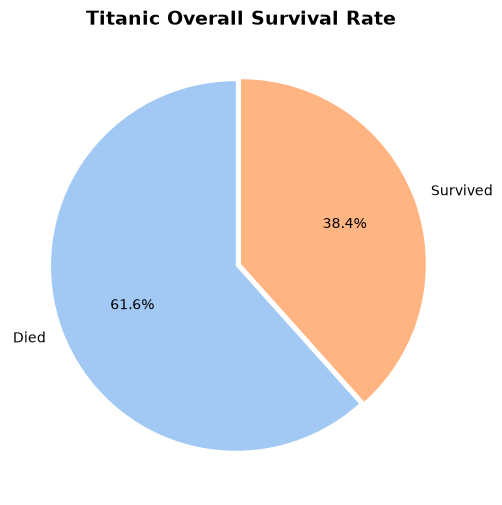

In [12]:
survival_counts = df["Survived"].value_counts()
labels = survival_counts.index.map({0: "Died", 1: "Survived"})

colors = sns.color_palette("pastel")[0:2]

plt.figure(figsize=(6, 6))
plt.pie(
    survival_counts,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",  
    startangle=90,  
    explode=(0.03, 0)

)

plt.title("Titanic Overall Survival Rate", fontsize=14, fontweight="bold")
plt.show()

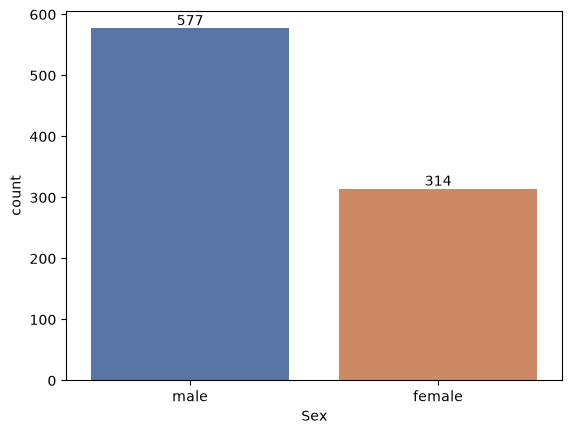

In [13]:
ax = sns.countplot(x="Sex", hue="Sex", data=df, palette="deep")
for container in ax.containers:
    ax.bar_label(container)

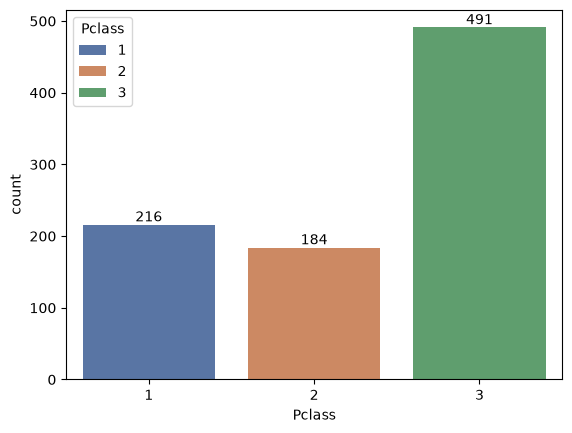

In [14]:
ax = sns.countplot(x="Pclass", hue="Pclass", data=df, palette="deep")
for container in ax.containers:
    ax.bar_label(container)

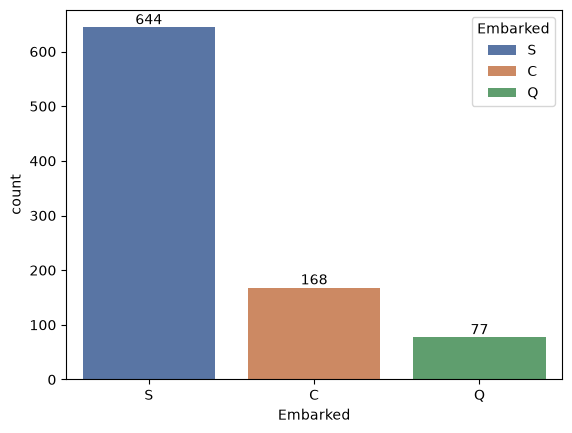

In [15]:
ax = sns.countplot(x='Embarked', hue='Embarked', data=df, palette="deep")
for container in ax.containers:
    ax.bar_label(container)

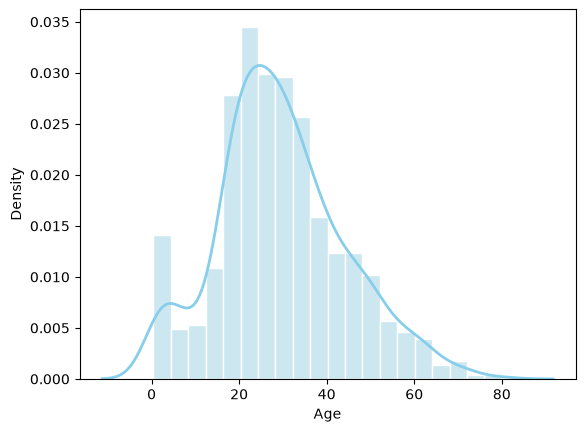

In [16]:
sns.histplot(df["Age"], color="lightblue", edgecolor="white", stat="density", alpha=0.6)
sns.kdeplot(df["Age"], color="skyblue", linewidth=2);

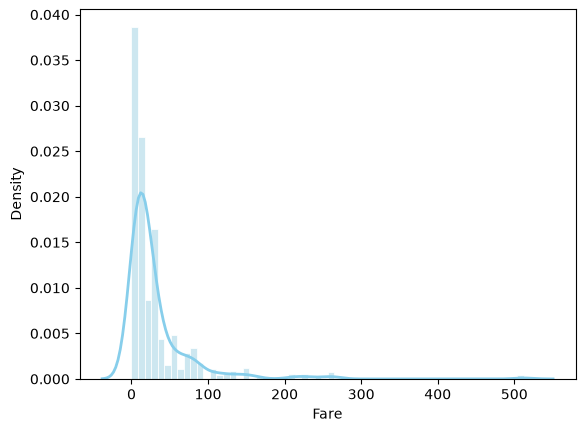

In [17]:
sns.histplot(df["Fare"], color="lightblue", edgecolor="white", stat="density", alpha=0.6)
sns.kdeplot(df["Fare"], color="skyblue", linewidth=2);

### Bivariate Analysis

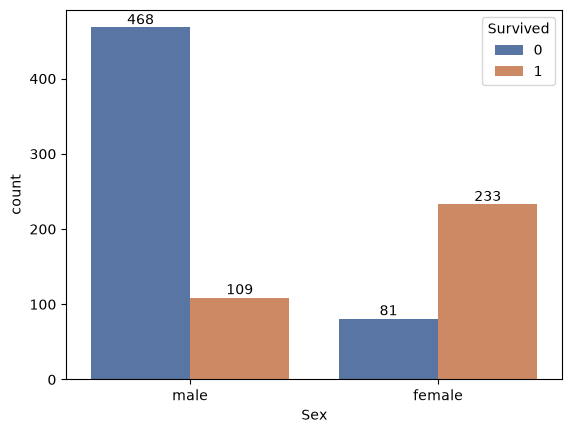

In [18]:
ax = sns.countplot(x = "Sex", hue="Survived", data=df, palette="deep");
for container in ax.containers:
    ax.bar_label(container)

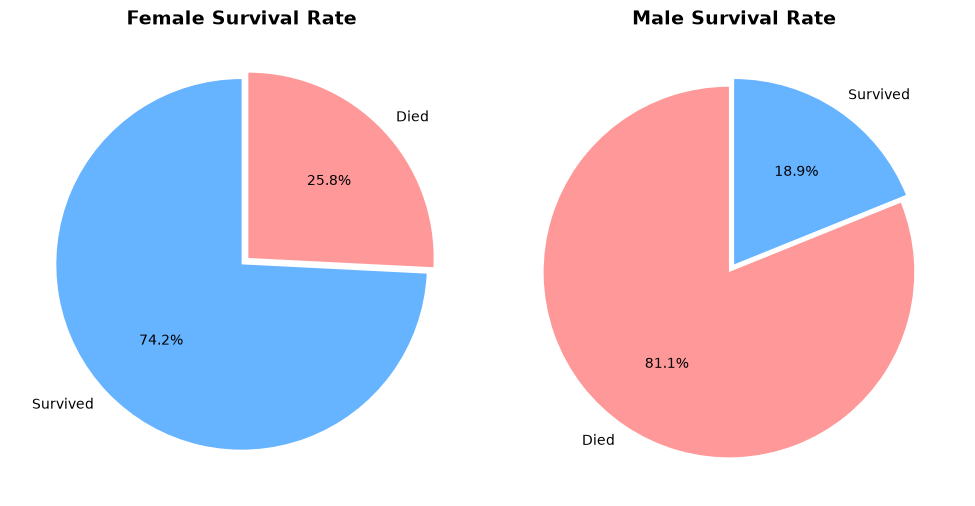

In [19]:

female_data = df[df["Sex"] == "female"]["Survived"].value_counts()
male_data = df[df["Sex"] == "male"]["Survived"].value_counts()

labels_map = {0: "Died", 1: "Survived"}
female_labels = female_data.index.map(labels_map)
male_labels = male_data.index.map(labels_map)

male_colors = ["#ff9999", "#66b3ff"]
female_colors = ["#66b3ff","#ff9999"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.pie(
    female_data,
    labels=female_labels,
    colors=female_colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.05),  
)
ax1.set_title("Female Survival Rate", fontsize=14, fontweight="bold")


ax2.pie(
    male_data,
    labels=male_labels,
    colors=male_colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0),  
)
ax2.set_title("Male Survival Rate", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


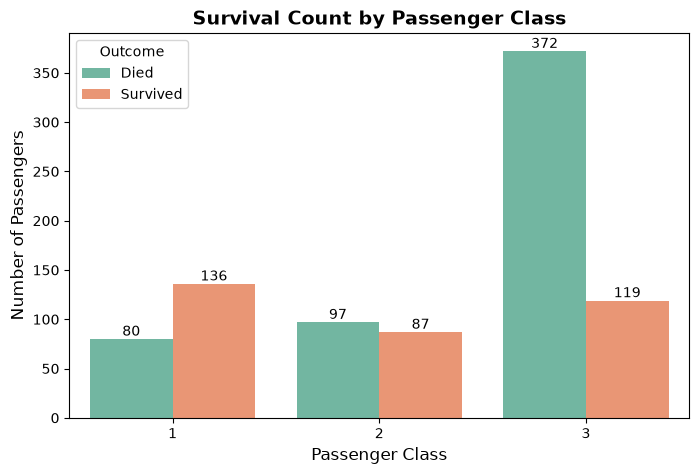

In [20]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set2")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Survival Count by Passenger Class", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.legend(title="Outcome", labels=["Died", "Survived"]);

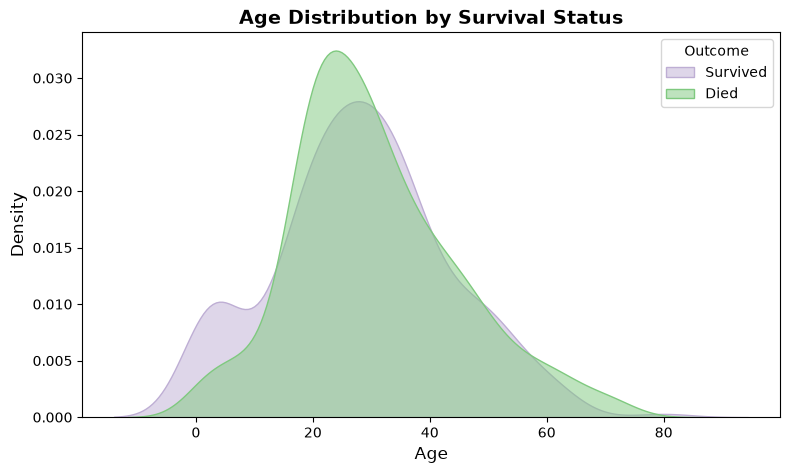

In [21]:
plt.figure(figsize=(9, 5))

sns.kdeplot(data=df, x="Age", hue="Survived", fill=True, common_norm=False, palette="Accent", alpha=0.5)

plt.title("Age Distribution by Survival Status", fontsize=14, fontweight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Outcome", labels=["Survived", "Died"]);

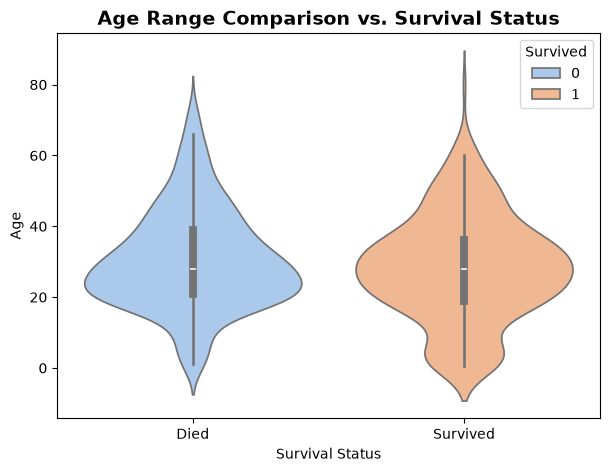

In [22]:
plt.figure(figsize=(7, 5))

sns.violinplot(data=df, x="Survived", y="Age", hue="Survived", palette="pastel")

plt.title("Age Range Comparison vs. Survival Status", fontsize=14, fontweight="bold")
plt.xticks([0, 1], ["Died", "Survived"])
plt.xlabel("Survival Status")
plt.ylabel("Age");

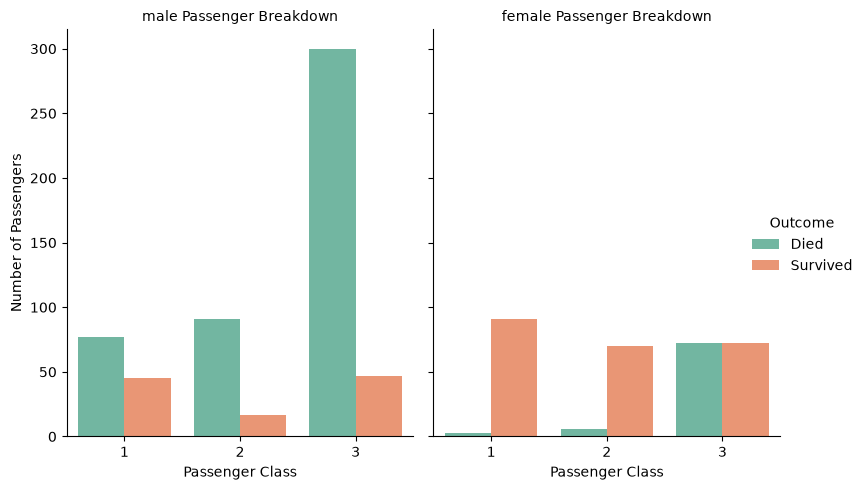

In [23]:

g = sns.catplot(
    data=df, 
    x="Pclass", 
    hue="Survived", 
    col="Sex", 
    kind="count", 
    palette="Set2",
    height=5, 
    aspect=0.8
)

g.set_axis_labels("Passenger Class", "Number of Passengers")
g.set_titles("{col_name} Passenger Breakdown")
g._legend.set_title("Outcome")
new_labels = ['Died', 'Survived']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

plt.show()


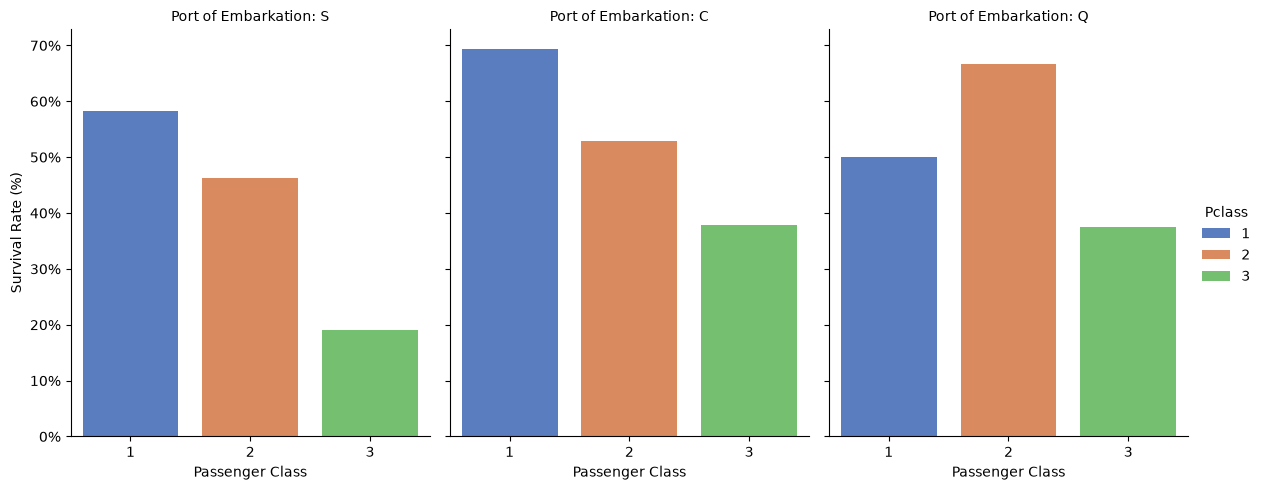

In [24]:

g = sns.catplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Pclass",
    col="Embarked",
    kind="bar",
    palette="muted",
    errorbar=None,
    height=5,
    aspect=0.8,
)


g.set_axis_labels("Passenger Class", "Survival Rate (%)")
g.set_titles("Port of Embarkation: {col_name}")

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: "{:.0%}".format(y))
    )

plt.show()


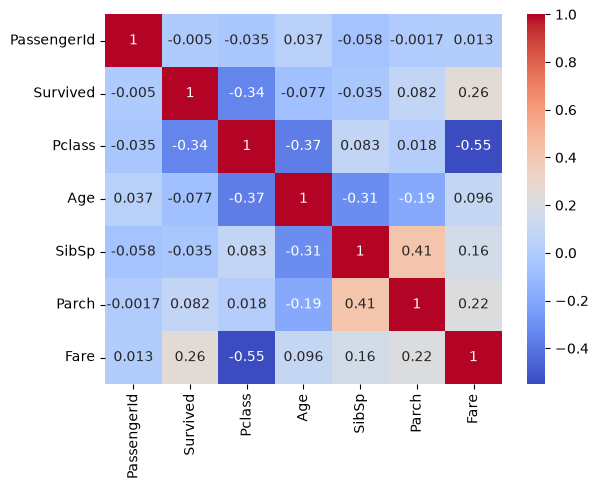

In [25]:
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm");

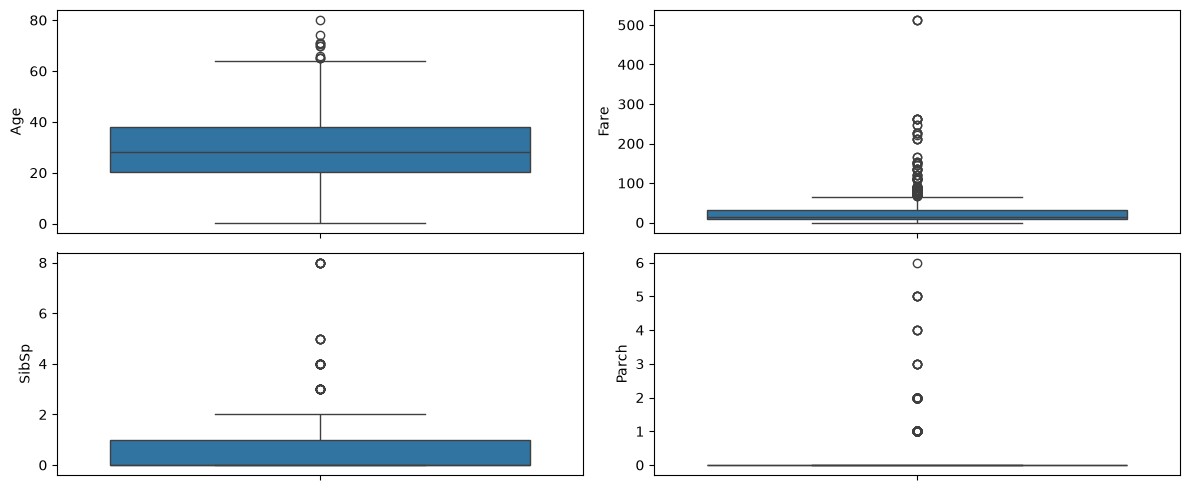

In [26]:

num_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2,2, figsize=(12,5))

sns.boxplot(df["Age"], ax=axes[0,0])
sns.boxplot(df["Fare"], ax=axes[0,1])
sns.boxplot(df["SibSp"], ax=axes[1,0])
sns.boxplot(df["Parch"], ax=axes[1,1])
plt.tight_layout();

## 4. Feature Selection & Data Splitting

In [27]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X.shape, y.shape

((891, 11), (891,))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 11), (179, 11), (712,), (179,))

In [29]:
X_train.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
736,737,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.3750,NaN,S
448,449,3,"Baclini, Miss. Marie Catherine",female,5.0,2,1,2666,19.2583,NaN,C
338,339,3,"Dahl, Mr. Karl Edwart",male,45.0,0,0,7598,8.0500,NaN,S
470,471,3,"Keefe, Mr. Arthur",male,NaN,0,0,323592,7.2500,NaN,S
757,758,2,"Bailey, Mr. Percy Andrew",male,18.0,0,0,29108,11.5000,NaN,S


In [30]:
X_train['Title'] = X_train['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
X_test['Title'] = X_test['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)

In [31]:
title_mapping = {
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Lady': 'Rare',
    'Countess': 'Rare',
    'Capt': 'Rare',
    'Col': 'Rare',
    'Don': 'Rare',
    'Dr': 'Rare',
    'Major': 'Rare',
    'Rev': 'Rare',
    'Sir': 'Rare',
    'Jonkheer': 'Rare',
    'the Countess': 'Rare',
    'Dona': 'Rare'
}

X_train['Title'] = X_train['Title'].replace(title_mapping)
X_test['Title'] = X_test['Title'].replace(title_mapping)


In [32]:
title_medians = X_train.groupby('Title')['Age'].median()
title_medians

Title
Master     3.0
Miss      22.0
Mr        30.0
Mrs       35.0
Rare      49.0
Name: Age, dtype: float64

In [33]:
X_train['HasCabin'] = X_train['Cabin'].notna().astype(int)
X_test['HasCabin'] = X_test['Cabin'].notna().astype(int)

X_train['Deck'] = X_train['Cabin'].fillna('M').astype(str).str[0].str.upper()
X_test['Deck'] = X_test['Cabin'].fillna('M').astype(str).str[0].str.upper()

ticket_counts = X_train['Ticket'].value_counts()
X_train['TicketGroupSize'] = X_train['Ticket'].map(ticket_counts)
X_test['TicketGroupSize'] = X_test['Ticket'].map(ticket_counts).fillna(1).astype(int)

X_train['FamilySize'] = X_train['SibSp'] + X_train['Parch'] + 1
X_test['FamilySize'] = X_test['SibSp'] + X_test['Parch'] + 1

X_train['MaxGroupSize'] = X_train[['FamilySize', 'TicketGroupSize']].max(axis=1)
X_test['MaxGroupSize'] = X_test[['FamilySize', 'TicketGroupSize']].max(axis=1)



In [34]:
columns_to_drop = ['PassengerId','Name', 'Ticket', 'Cabin']
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

In [35]:
X_train.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,Deck,TicketGroupSize,FamilySize,MaxGroupSize
677,3,female,18.0,0,0,9.8417,S,Miss,0,M,1,1,1
298,1,male,NaN,0,0,30.5000,S,Mr,1,C,1,1,1
605,3,male,36.0,1,0,15.5500,S,Mr,0,M,1,2,2
843,3,male,34.5,0,0,6.4375,C,Mr,0,M,1,1,1
22,3,female,15.0,0,0,8.0292,Q,Miss,0,M,1,1,1


In [36]:
X_test.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,Deck,TicketGroupSize,FamilySize,MaxGroupSize
596,2,female,NaN,0,0,33.00,S,Miss,0,M,2,1,2
749,3,male,31.0,0,0,7.75,Q,Mr,0,M,1,1,1
297,1,female,2.0,1,2,151.55,S,Miss,1,C,3,4,4
886,2,male,27.0,0,0,13.00,S,Rare,0,M,1,1,1
252,1,male,62.0,0,0,26.55,S,Mr,1,C,1,1,1


## 5. Build Preprocessing Pipeline

In [37]:
class TitleAgeImputer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.title_medians_ = {}
        self.global_median_ = None

    def fit(self, X, y=None):
        X_copy = X.copy()

        self.title_medians_ = (
            X_copy
            .groupby("Title")["Age"]
            .median()
            .to_dict()
        )

        self.global_median_ = X_copy["Age"].median()

        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy["Age"] = (
            X_copy["Age"]
            .fillna(
                X_copy["Title"].map(self.title_medians_)
            )
            .fillna(self.global_median_)
        )

        return X_copy

In [38]:
fare_feature = ["Fare"]
other_numeric_features  = ["Age", "SibSp", "Parch", "TicketGroupSize", "FamilySize", "MaxGroupSize"]
categorical_features = ["Sex", "Embarked", "Pclass", "Title", "Deck", "HasCabin"]

fare_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("fare_path", fare_transformer, fare_feature),
        ("num_path", numeric_transformer, other_numeric_features),
        ("cat_path", categorical_transformer, categorical_features),
    ]
)

final_pipeline = Pipeline(
    steps=[("title_age_imputer", TitleAgeImputer()), ("preprocessor", preprocessor)]
)

X_train_processed = final_pipeline.fit_transform(X_train)
X_test_processed = final_pipeline.transform(X_test)


In [39]:
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
X_train_visual = pd.DataFrame(X_train_processed, columns=feature_names)
X_train_visual.head()

,fare_path__Fare,num_path__Age,num_path__SibSp,num_path__Parch,num_path__TicketGroupSize,num_path__FamilySize,num_path__MaxGroupSize,cat_path__Sex_female,cat_path__Sex_male,cat_path__Embarked_C,...,cat_path__Deck_B,cat_path__Deck_C,cat_path__Deck_D,cat_path__Deck_E,cat_path__Deck_F,cat_path__Deck_G,cat_path__Deck_M,cat_path__Deck_T,cat_path__HasCabin_0,cat_path__HasCabin_1
0,1.124592,0.033471,-0.465084,-0.466183,3.954909,-0.556339,2.404544,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-3.014278,0.033471,-0.465084,-0.466183,-0.549082,-0.556339,-0.634212,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,2.508198,0.033471,-0.465084,-0.466183,-0.549082,-0.556339,-0.634212,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.627019,-0.872714,-0.465084,0.727782,-0.549082,0.073412,-0.026461,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.361872,0.108986,0.478335,0.727782,0.351716,0.703162,0.581290,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 6. Model Selection & Baseline Training

In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

print("--- 5-Fold Cross-Validation Accuracy ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

--- 5-Fold Cross-Validation Accuracy ---
Logistic Regression: 0.8203 (+/- 0.0233)
SVC: 0.8231 (+/- 0.0151)
Random Forest: 0.8049 (+/- 0.0374)
Gradient Boosting: 0.8231 (+/- 0.0283)
XGBoost: 0.7852 (+/- 0.0269)
LightGBM: 0.8077 (+/- 0.0304)


## 7. Hyperparameter Tuning and Final Model Selection

In [41]:
grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "penalty": ["l2"],
            "solver": ["lbfgs", "liblinear"]
        }
    },
    "SVC": {
        "model": SVC(random_state=42),
        "params": {
            "C": [0.1, 1, 10, 100],
            "gamma": ["scale", "auto", 0.01, 0.1],
            "kernel": ["rbf", "linear"]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators":[50, 100, 150, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth":[3, 6, 8],
            "min_samples_split": [2, 5, 10]
        }
    }
}

In [42]:
best_models = {}

print("--- Starting Hyperparameter Tuning ---")
for name, config in grids.items():
    print(f"Tuning {name}...")
    
    
    grid_search = GridSearchCV(
        estimator=config["model"], 
        param_grid=config["params"], 
        cv=5, 
        scoring="accuracy", 
        n_jobs=-1
    )
    
    grid_search.fit(X_train_processed, y_train)
    
    print(f"-> Best {name} Params: {grid_search.best_params_}")
    print(f"-> Best {name} Tuned Score: {grid_search.best_score_:.4f}\n")
    
    best_models[name] = {
        "score": grid_search.best_score_,
        "estimator": grid_search.best_estimator_
    }


--- Starting Hyperparameter Tuning ---
Tuning Logistic Regression...


c:\Users\Advance Pc\Desktop\end-to-end-ml-projects\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


-> Best Logistic Regression Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
-> Best Logistic Regression Tuned Score: 0.8273

Tuning SVC...
-> Best SVC Params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
-> Best SVC Tuned Score: 0.8357

Tuning Gradient Boosting...
-> Best Gradient Boosting Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
-> Best Gradient Boosting Tuned Score: 0.8260



In [43]:
final_model = best_models["SVC"]["estimator"]

print(f"Final Model Locked: {final_model}")


Final Model Locked: SVC(C=10, gamma=0.1, random_state=42)


## 8.  Modeling & Iterative Improvement

### Second Iteration (Attempt)

In [46]:
internal_preds = final_model.predict(X_test_processed)

In [47]:
val_analysis = X_test.copy()
val_analysis['True_Survived'] = y_test
val_analysis['Predicted_Survived'] = internal_preds

errors = val_analysis[val_analysis['True_Survived'] != val_analysis['Predicted_Survived']]

print(f"The model made {len(errors)} mistakes out of {len(y_test)} passengers.")
errors.sample(10)


The model made 39 mistakes out of 179 passengers.


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,Deck,TicketGroupSize,FamilySize,MaxGroupSize,True_Survived,Predicted_Survived
745,1,male,70.0,1,1,71.000,S,Rare,1,B,1,3,3,0,1
570,2,male,62.0,0,0,10.500,S,Mr,0,M,1,1,1,1,0
431,3,female,NaN,1,0,16.100,S,Mrs,0,M,1,2,2,1,0
142,3,female,24.0,1,0,15.850,S,Mrs,0,M,1,2,2,1,0
607,1,male,27.0,0,0,30.500,S,Mr,0,M,1,1,1,1,0
804,3,male,27.0,0,0,6.975,S,Mr,0,M,1,1,1,1,0
17,2,male,NaN,0,0,13.000,S,Mr,0,M,1,1,1,1,0
106,3,female,21.0,0,0,7.650,S,Miss,0,M,1,1,1,1,0
587,1,male,60.0,1,1,79.200,C,Mr,1,B,1,3,3,1,0
690,1,male,31.0,1,0,57.000,S,Mr,1,B,1,2,2,1,0


In [48]:
internal_preds = final_model.predict(X_test_processed)
print(f"Internal Validation Accuracy: {accuracy_score(y_test, internal_preds):.4f}")

Internal Validation Accuracy: 0.7821


* Our model generalize that "if Sex == male and Title == Mr, then predict Died" and also that if "Sex == female, then predict Survived"

* To fix this we need to create Interaction Features (forces model to look at combination of features together rather than looking at Sex, Pclass and Title in isolation).

In [49]:

X_train["Sex_Pclass"] = X_train["Sex"] + "_" + X_train["Pclass"].astype(str)
X_test["Sex_Pclass"] = X_test["Sex"] + "_" + X_test["Pclass"].astype(str)

def create_age_class_interaction(X):
    X_copy = X.copy()
    X_copy["Age_Class"] = X_copy["Age"] * X_copy["Pclass"].astype(float)
    return X_copy


fare_feature = ["Fare"]
other_numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "TicketGroupSize",
    "FamilySize",
    "MaxGroupSize",
    "Age_Class",
]
categorical_features = [
    "Sex",
    "Embarked",
    "Pclass",
    "Title",
    "Deck",
    "HasCabin",
    "Sex_Pclass",  
]


fare_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "log",
            FunctionTransformer(
                np.log1p, validate=False, feature_names_out="one-to-one"
            ),
        ),
        ("scaler", StandardScaler()),
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("fare_path", fare_transformer, fare_feature),
        ("num_path", numeric_transformer, other_numeric_features),
        ("cat_path", categorical_transformer, categorical_features),
    ]
)


final_pipeline = Pipeline(
    steps=[
        (
            "title_age_imputer",
            TitleAgeImputer(),
        ), 
        (
            "age_class_generator",
            FunctionTransformer(create_age_class_interaction, validate=False),
        ),  
        ("preprocessor", preprocessor),
    ]
)


X_train_processed = final_pipeline.fit_transform(X_train)
X_test_processed = final_pipeline.transform(X_test)


In [50]:
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
X_train_visual = pd.DataFrame(X_train_processed, columns=feature_names)
X_train_visual.head()

,fare_path__Fare,num_path__Age,num_path__SibSp,num_path__Parch,num_path__TicketGroupSize,num_path__FamilySize,num_path__MaxGroupSize,num_path__Age_Class,cat_path__Sex_female,cat_path__Sex_male,...,cat_path__Deck_M,cat_path__Deck_T,cat_path__HasCabin_0,cat_path__HasCabin_1,cat_path__Sex_Pclass_female_1,cat_path__Sex_Pclass_female_2,cat_path__Sex_Pclass_female_3,cat_path__Sex_Pclass_male_1,cat_path__Sex_Pclass_male_2,cat_path__Sex_Pclass_male_3
0,1.124592,0.033471,-0.465084,-0.466183,3.954909,-0.556339,2.404544,0.753521,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-3.014278,0.033471,-0.465084,-0.466183,-0.549082,-0.556339,-0.634212,-0.133834,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2.508198,0.033471,-0.465084,-0.466183,-0.549082,-0.556339,-0.634212,-1.021189,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.627019,-0.872714,-0.465084,0.727782,-0.549082,0.073412,-0.026461,-0.311305,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.361872,0.108986,0.478335,0.727782,0.351716,0.703162,0.581290,-0.074677,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

print("--- 5-Fold Cross-Validation Accuracy ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

--- 5-Fold Cross-Validation Accuracy ---
Logistic Regression: 0.8259 (+/- 0.0201)
SVC: 0.8259 (+/- 0.0169)
Random Forest: 0.7965 (+/- 0.0500)
Gradient Boosting: 0.8147 (+/- 0.0351)
XGBoost: 0.7965 (+/- 0.0377)
LightGBM: 0.8105 (+/- 0.0351)


In [52]:
grids = {
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators":[50, 100, 150, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth":[3, 4, 6, 8],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["lbfgs", "liblinear"] 
        }
    },
    "SVC": {
        "model": SVC(random_state=42),
        "params": {
            "C": [0.1, 1, 10, 100],
            "gamma": ["scale", "auto", 0.01, 0.1],
            "kernel": ["rbf", "linear"]
        }
    }
}

In [53]:
best_models = {}

print("--- Starting Final Hyperparameter Tuning ---")
for name, config in grids.items():
    print(f"Tuning {name}...")
    
    grid_search = GridSearchCV(
        estimator=config["model"], 
        param_grid=config["params"], 
        cv=5, 
        scoring="accuracy", 
        n_jobs=-1
    )
    
    grid_search.fit(X_train_processed, y_train)
    
    print(f"-> Best {name} Params: {grid_search.best_params_}")
    print(f"-> Best {name} Tuned Score: {grid_search.best_score_:.4f}\n")
    
    best_models[name] = {
        "score": grid_search.best_score_,
        "estimator": grid_search.best_estimator_
    }

--- Starting Final Hyperparameter Tuning ---
Tuning Gradient Boosting...
-> Best Gradient Boosting Params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
-> Best Gradient Boosting Tuned Score: 0.8246

Tuning Logistic Regression...
-> Best Logistic Regression Params: {'C': 0.1, 'solver': 'lbfgs'}
-> Best Logistic Regression Tuned Score: 0.8357

Tuning SVC...
-> Best SVC Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
-> Best SVC Tuned Score: 0.8315



In [55]:
final_model = best_models["Logistic Regression"]["estimator"]
print(f"Final Production Model Locked: {final_model}")



Final Production Model Locked: LogisticRegression(C=0.1, max_iter=1000, random_state=42)


The Kaggle score for this model is **0.75119**

### Third Iteration (Improve features)

In [3]:
def engineer_titanic_features(df, training_ticket_counts=None):
    """
    Create leakage-safe Titanic features.

    Parameters
    ----------
    df : pd.DataFrame
        Raw Titanic passenger data.
    training_ticket_counts : pd.Series, optional
        Ticket counts learned from the training data.
        Must be supplied when transforming validation/test data.
    """
    df_copy = df.copy()

    df_copy["Title"] = df_copy["Name"].str.extract(
        r",\s*([^\.]+)\.",
        expand=False
    )

    df_copy["Title"] = df_copy["Title"].replace(title_mapping)

    df_copy["HasCabin"] = df_copy["Cabin"].notna().astype(int)

    df_copy["Deck"] = (
        df_copy["Cabin"]
        .fillna("M")
        .astype(str)
        .str[0]
        .str.upper()
    )

    if training_ticket_counts is None:
        training_ticket_counts = df_copy["Ticket"].value_counts()

    df_copy["TicketGroupSize"] = (
        df_copy["Ticket"]
        .map(training_ticket_counts)
        .fillna(1)
        .astype(int)
    )

    df_copy["FamilySize"] = (
        df_copy["SibSp"] +
        df_copy["Parch"] +
        1
    )

    df_copy["IsAlone"] = (
        df_copy["FamilySize"] == 1
    ).astype(int)

    df_copy["MaxGroupSize"] = df_copy[
        ["FamilySize", "TicketGroupSize"]
    ].max(axis=1)

 
    df_copy["FarePerPerson"] = (
        df_copy["Fare"] /
        df_copy["TicketGroupSize"].replace(0, 1)
    )


    df_copy["AgeGroup"] = pd.cut(
        df_copy["Age"],
        bins=[-np.inf, 12, 18, 30, 50, np.inf],
        labels=[
            "Child",
            "Teen",
            "YoungAdult",
            "Adult",
            "Senior"
        ]
    )


    df_copy["TicketPrefix"] = (
        df_copy["Ticket"]
        .astype(str)
        .str.replace(r"\d", "", regex=True)
        .str.replace(r"[\s\./]+", "", regex=True)
        .replace("", "NONE")
        .str.upper()
    )


    df_copy["Sex_Pclass"] = (
        df_copy["Sex"] +
        "_" +
        df_copy["Pclass"].astype(str)
    )


    df_copy = df_copy.set_index("PassengerId")

    columns_to_drop = [
        "Name",
        "Ticket",
        "Cabin"
    ]

    df_copy = df_copy.drop(columns=columns_to_drop)

    return df_copy, training_ticket_counts

In [4]:
fare_feature = [
    "Fare",
    "FarePerPerson"
]

numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "TicketGroupSize",
    "FamilySize",
    "MaxGroupSize",
    "IsAlone"
]

categorical_features = [
    "Sex",
    "Embarked",
    "Pclass",
    "Title",
    "Deck",
    "HasCabin",
    "AgeGroup",
    "TicketPrefix",
    "Sex_Pclass"
]

In [5]:
fare_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one"
        )),
        ("scaler", StandardScaler())
    ]
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("fare", fare_transformer, fare_feature),
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [66]:
def make_model_pipeline(model):
    return Pipeline(
        steps=[
            ("title_age_imputer", TitleAgeImputer()),
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

In [67]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [73]:
train_data = pd.read_csv(data_path)
X = train_data.drop("Survived", axis=1)
y = train_data["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [84]:
X_train_engineered, final_ticket_counts = engineer_titanic_features(X_train)
X_test_engineered, final_ticket_counts = engineer_titanic_features(X_test)

In [85]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "SVC": SVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )
}

results = {}

print("--- Iteration 3: Leakage-Safe 5-Fold Cross-Validation ---")

for name, model in models.items():

    pipeline = make_model_pipeline(model)

    scores = cross_val_score(
        pipeline,
        X_train_engineered,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    results[name] = scores

    print(
        f"{name}: "
        f"{scores.mean():.4f} "
        f"(+/- {scores.std():.4f})"
    )

--- Iteration 3: Leakage-Safe 5-Fold Cross-Validation ---
Logistic Regression: 0.8245 (+/- 0.0221)
SVC: 0.8329 (+/- 0.0263)
Random Forest: 0.8216 (+/- 0.0133)
Gradient Boosting: 0.8357 (+/- 0.0284)
XGBoost: 0.8006 (+/- 0.0121)
LightGBM: 0.8175 (+/- 0.0162)


In [86]:
model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10, 100]
        }
    },

    "SVC": {
        "model": SVC(
            random_state=42
        ),
        "params": {
            "classifier__C": [0.1, 1, 10, 100],
            "classifier__gamma": [
                "scale",
                "auto",
                0.01,
                0.1
            ],
            "classifier__kernel": [
                "rbf",
                "linear"
            ]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            random_state=42
        ),
        "params": {
            "classifier__n_estimators": [
                50, 100, 150
            ],
            "classifier__learning_rate": [
                0.01, 0.05, 0.1
            ],
            "classifier__max_depth": [
                2, 3, 4, 5
            ],
            "classifier__min_samples_split": [
                2, 5, 10
            ]
        }
    }
}

In [88]:
best_models = {}

print("--- Iteration 3: Leakage-Safe Hyperparameter Tuning ---")

for name, config in model_configs.items():

    pipeline = make_model_pipeline(config["model"])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train_engineered, y_train)

    print(f"\n{name}")
    print("Best Parameters:", grid_search.best_params_)
    print(
        f"Best CV Accuracy: "
        f"{grid_search.best_score_:.4f}"
    )

    best_models[name] = grid_search

--- Iteration 3: Leakage-Safe Hyperparameter Tuning ---

Logistic Regression
Best Parameters: {'classifier__C': 10}
Best CV Accuracy: 0.8259

SVC
Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best CV Accuracy: 0.8329

Gradient Boosting
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 150}
Best CV Accuracy: 0.8413


In [89]:
best_name = max(
    best_models,
    key=lambda name: best_models[name].best_score_
)

final_model = best_models[best_name].best_estimator_

print(f"Final Model Selected: {best_name}")
print(
    f"Leakage-Safe CV Accuracy: "
    f"{best_models[best_name].best_score_:.4f}"
)

Final Model Selected: Gradient Boosting
Leakage-Safe CV Accuracy: 0.8413


In [92]:
final_model.fit(X_train_engineered, y_train)

holdout_predictions = final_model.predict(X_test_engineered)

holdout_accuracy = accuracy_score(
    y_test,
    holdout_predictions
)

print(
    f"Iteration 3 Holdout Accuracy: "
    f"{holdout_accuracy:.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        holdout_predictions
    )
)

Iteration 3 Holdout Accuracy: 0.7989

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [93]:
val_analysis = X_test.copy()

val_analysis["True_Survived"] = y_test.values
val_analysis["Predicted_Survived"] = holdout_predictions

errors = val_analysis[
    val_analysis["True_Survived"] !=
    val_analysis["Predicted_Survived"]
]

print(
    f"Iteration 3 made {len(errors)} "
    f"mistakes out of {len(y_test)} passengers."
)

errors.head(10)

Iteration 3 made 36 mistakes out of 179 passengers.


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,True_Survived,Predicted_Survived
553,554,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C,1,0
559,560,3,"de Messemaeker, Mrs. Guillaume Joseph (Emma)",female,36.0,1,0,345572,17.4000,NaN,S,1,0
536,537,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.5500,B38,S,0,1
698,699,1,"Thayer, Mr. John Borland",male,49.0,1,1,17421,110.8833,C68,C,0,1
712,713,1,"Taylor, Mr. Elmer Zebley",male,48.0,1,0,19996,52.0000,C126,S,1,0
455,456,3,"Jalsevac, Mr. Ivan",male,29.0,0,0,349240,7.8958,NaN,C,1,0
489,490,3,"Coutts, Master. Eden Leslie ""Neville""",male,9.0,1,1,C.A. 37671,15.9000,NaN,S,1,0
165,166,3,"Goldsmith, Master. Frank John William ""Frankie""",male,9.0,0,2,363291,20.5250,NaN,S,1,0
745,746,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S,0,1
297,298,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,0,1


The Kaggle score for this model is **0.74880**

### Fourth Iteration

In [10]:
train_data = pd.read_csv(data_path)

In [7]:
class AgeImputer (BaseEstimator, TransformerMixin):

    def __init__(self):
        self.medians_ = {}
        self.global_median_ = None

    def _clean_title_string(self, title):
        if title == "Mme": return "Mrs"
        elif title in ["Mlle", "Ms"]: return "Miss"
        elif title in ["Countess", "Lady", "Sir", "Don", "Jonkheer"]: return "Royalty"
        elif title in ["Col", "Major", "Capt", "Dr", "Rev"]: return "Professional"
        return title

    def fit(self, x, y=None):
        x_df = pd.DataFrame(x).copy()
        titles = x_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        x_df['Title'] = titles.apply(self._clean_title_string)
        self.medians_ = x_df.groupby("Title")['Age'].median().to_dict()
        self.global_median_ = x_df["Age"].median()
        return self


    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        titles = x_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        x_df['Title'] = titles.apply(self._clean_title_string)

        x_df["Age"] = x_df.apply(
            lambda row: row['Age'] if pd.notnull(row['Age'])
            else self.medians_.get(row['Title'], self.global_median_), 
            axis=1
        )
        return x_df

In [8]:
class EmbarkedImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mode_ = None
        
    def fit(self,x, y=None):
        x_df = pd.DataFrame(x).copy()
        self.mode_ = x_df["Embarked"].mode()[0]
        return self
        
    def transform(self,x):
        x_df = pd.DataFrame(x).copy()
        x_df["Embarked"] = x_df.apply(
            lambda row: row['Embarked'] if pd.notnull(row["Embarked"])
            else self.mode_,
            axis = 1
        )

        return x_df

In [9]:
class CabinImputer(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        x_df['Cabin'] = x_df['Cabin'].notnull().astype(int)
        return x_df
        

In [10]:
class TicketImputer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.ticket_counts_ = {}

    def fit(self, x, y=None):
        x_df = pd.DataFrame(x).copy()
        self.ticket_counts_ = x_df["Ticket"].value_counts().to_dict()
        return self

    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        x_df['TicketGroupSize'] = x_df['Ticket'].map(self.ticket_counts_).fillna(1).astype(int)

        conditions = [
            (x_df['TicketGroupSize'] == 1),
            (x_df["TicketGroupSize"] >=2 ) & (x_df["TicketGroupSize"] <=4),
            (x_df["TicketGroupSize"] > 4)
        ]
        choices = ["Alone", "SmallGroup", "LargeGroup"]
        x_df["GroupType"] = np.select(conditions, choices, default="Alone")
        return x_df.drop(columns=["Name","PassengerId","Ticket"])

In [11]:
class LogFareTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, x, y=None):
        return self 

    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        
        if 'Fare' in x_df.columns:
            x_df['Log Fare'] = np.log1p(x_df['Fare'])
            
        return x_df

In [12]:
class UniversalBackupImputer(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.numeric_defaults_ = {}
        self.categorical_defaults_ = {}

    def fit(self, x, y=None):
        x_df = pd.DataFrame(x).copy()

        num_cols = x_df.select_dtypes(include=[np.number]).columns
        cat_cols = x_df.select_dtypes(exclude=[np.number]).columns

        for col in num_cols:
            self.numeric_defaults_[col] = x_df[col].median()

        for col in cat_cols:
            if not x_df[col].mode().empty:
                self.categorical_defaults_[col] = x_df[col].mode()[0]
            else:
                self.categorical_defaults_[col] = "Missing"

        return self

    def transform(self, x):
        x_df = pd.DataFrame(x).copy()
        for col, median_val in self.numeric_defaults_.items():
            if col in x_df.columns:
                x_df[col] = x_df[col].fillna(median_val)

        for col, mode_val in self.categorical_defaults_.items():
            if col in x_df.columns:
                x_df[col] = x_df[col].fillna(mode_val)

        return x_df


In [11]:
preprocessor = ColumnTransformer(
    transformers= [
        ('cat', OneHotEncoder(sparse_output= False,handle_unknown='ignore'),['Sex','Title','GroupType', 'Embarked'])
    ],
    remainder = 'passthrough'
)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [12]:
full_pipeline = Pipeline([
    ('age_imputer', AgeImputer()),
    ('embarked_imputer', EmbarkedImputer()),
    ('cabin_imputer', CabinImputer()),
    ('ticket_imputer', TicketImputer()),
    ('log_fare', LogFareTransformer()),
    ('encoding_and_scaling', preprocessor)
])


In [13]:
X = train_data.drop(columns=['Survived'])
y = train_data['Survived']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train_processed = full_pipeline.fit_transform(X_train, y_train)
X_test_processed = full_pipeline.transform(X_test)

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

print("--- 5-Fold Cross-Validation Accuracy ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

--- 5-Fold Cross-Validation Accuracy ---
Logistic Regression: 0.8314 (+/- 0.0186)
SVC: 0.6755 (+/- 0.0130)
Random Forest: 0.8091 (+/- 0.0267)
Gradient Boosting: 0.8258 (+/- 0.0185)
XGBoost: 0.8020 (+/- 0.0083)
LightGBM: 0.8160 (+/- 0.0214)


In [17]:
grids = {
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators":[50, 100, 150, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth":[3, 4, 6, 8],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["lbfgs", "liblinear"] 
        }
    }
}

In [18]:
best_models = {}

print("--- Starting Final Hyperparameter Tuning ---")
for name, config in grids.items():
    print(f"Tuning {name}...")
    
    grid_search = GridSearchCV(
        estimator=config["model"], 
        param_grid=config["params"], 
        cv=5, 
        scoring="accuracy", 
        n_jobs=-1
    )
    
    grid_search.fit(X_train_processed, y_train)
    
    print(f"-> Best {name} Params: {grid_search.best_params_}")
    print(f"-> Best {name} Tuned Score: {grid_search.best_score_:.4f}\n")
    
    best_models[name] = {
        "score": grid_search.best_score_,
        "estimator": grid_search.best_estimator_
    }

--- Starting Final Hyperparameter Tuning ---
Tuning Gradient Boosting...
-> Best Gradient Boosting Params: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 150}
-> Best Gradient Boosting Tuned Score: 0.8300

Tuning Logistic Regression...
-> Best Logistic Regression Params: {'C': 1, 'solver': 'lbfgs'}
-> Best Logistic Regression Tuned Score: 0.8314



In [19]:
final_model = best_models["Logistic Regression"]["estimator"]
print(f"Final Production Model Locked: {final_model}")


Final Production Model Locked: LogisticRegression(C=1, max_iter=1000, random_state=42)


In [21]:
internal_preds = final_model.predict(X_test_processed)
val_analysis = X_test.copy()
val_analysis['True_Survived'] = y_test
val_analysis['Predicted_Survived'] = internal_preds

errors = val_analysis[val_analysis['True_Survived'] != val_analysis['Predicted_Survived']]

print(f"The model made {len(errors)} mistakes out of {len(y_test)} passengers.")
errors.sample(10)

The model made 32 mistakes out of 179 passengers.


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,True_Survived,Predicted_Survived
30,31,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C,0,1
772,773,2,"Mack, Mrs. (Mary)",female,57.0,0,0,S.O./P.P. 3,10.5000,E77,S,0,1
712,713,1,"Taylor, Mr. Elmer Zebley",male,48.0,1,0,19996,52.0000,C126,S,1,0
578,579,3,"Caram, Mrs. Joseph (Maria Elias)",female,NaN,1,0,2689,14.4583,NaN,C,0,1
357,358,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0000,NaN,S,0,1
621,622,1,"Kimball, Mr. Edwin Nelson Jr",male,42.0,1,0,11753,52.5542,D19,S,1,0
204,205,3,"Cohen, Mr. Gurshon ""Gus""",male,18.0,0,0,A/5 3540,8.0500,NaN,S,1,0
286,287,3,"de Mulder, Mr. Theodore",male,30.0,0,0,345774,9.5000,NaN,S,1,0
657,658,3,"Bourke, Mrs. John (Catherine)",female,32.0,1,1,364849,15.5000,NaN,Q,0,1
25,26,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S,1,0


The Kaggle score for this model is **0.76315**

## 9. Retrain on Full Data



In [22]:
full_train_data = pd.read_csv(data_path)

X_full = full_train_data.drop("Survived", axis=1)
y_full = full_train_data["Survived"]

full_pipeline = Pipeline([
    ('age_imputer', AgeImputer()),
    ('embarked_imputer', EmbarkedImputer()),
    ('cabin_imputer', CabinImputer()),
    ('ticket_imputer', TicketImputer()),
    ('log_fare', LogFareTransformer()),
    ("universal_backup_imputer", UniversalBackupImputer()),
    ('encoding_and_scaling', preprocessor),
    ('classifier', final_model)
])


full_pipeline.fit(X_full, y_full)
print("Master Pipeline trained on 100% of the raw training dataset successfully!")


Master Pipeline trained on 100% of the raw training dataset successfully!


## 10. Prediction & Export

In [139]:
test_df = pd.read_csv(
    os.path.join("..", "data", "test.csv")
)

training_fare_median = full_train_data["Fare"].median()
test_df["Fare"] = test_df["Fare"].fillna(training_fare_median)

final_predictions = full_pipeline.predict(test_df)


In [141]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": final_predictions.astype(int)
})

submission.to_csv(
    "../data/submission.csv",
    index=False
)

print("Submission created successfully.")

Submission created successfully.


**Deployment Note:** Leaving these custom transformers inside this notebook is fine for training and generating my Kaggle submissions; however, as I move toward deploying this pipeline into a production web application, I will need to transfer these custom classes into a separate Python file (`custom_transformer.py`) and import them directly to prevent `joblib` or `pickle` from throwing serialization link errors during deployment.

In [6]:
import sys
sys.path.append("..")
from custom_transformers import (
    AgeImputer,
    CabinImputer,
    EmbarkedImputer,
    LogFareTransformer,
    TicketImputer,
    UniversalBackupImputer,
)

In [23]:
full_pipeline.fit(X_full, y_full)
print("Master Pipeline trained on 100% of the raw training dataset successfully!")

Master Pipeline trained on 100% of the raw training dataset successfully!


In [24]:
joblib.dump(full_pipeline, "../model/titanic_pipeline.joblib")
print("Model pipeline successfully exported!")

Model pipeline successfully exported!
